# Health_CoRisk_Analyzer: Machine Learning Comparison

This notebook adds an exploratory machine-learning comparison to the cardiovascular risk project. It compares Logistic Regression, Decision Tree, and Random Forest classifiers. The analysis is supplementary and does not change or feed the Streamlit dashboard.

> **Important:** `High_Heart_Attack_Risk` is an exploratory classification target created from the median of the dataset's supplied heart-attack risk percentage. The supplied risk columns are excluded from the predictors to avoid target leakage. These models are not clinical diagnostic tools.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             RocCurveDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
DATA_PATH = '../Datasets/Patient_Comorbidity_Risk_Assessment_Dataset.csv'

## 1. Load data and define the target

In [2]:
df = pd.read_csv(DATA_PATH)
risk_cutoff = df['Heart_Attack_Risk_Percentage'].median()
df['High_Heart_Attack_Risk'] = (df['Heart_Attack_Risk_Percentage'] >= risk_cutoff).astype(int)

print(f'Dataset shape: {df.shape}')
print(f'Median risk cutoff: {risk_cutoff:.2f}%')
print(df['High_Heart_Attack_Risk'].value_counts(normalize=True).sort_index().rename({0: 'Lower risk', 1: 'Higher risk'}))

Dataset shape: (10000, 21)
Median risk cutoff: 15.90%
High_Heart_Attack_Risk
Lower risk     0.4987
Higher risk    0.5013
Name: proportion, dtype: float64


## 2. Prepare features without leakage

Patient ID and the two supplied risk-percentage columns are removed. This prevents the models from learning the answer directly from an identifier or from a risk score that was already present in the source data.

In [3]:
target = 'High_Heart_Attack_Risk'
excluded = [
    'Patient_ID',
    'Heart_Attack_Risk_Percentage',
    'Mortality_Risk_Percentage',
    target,
]
X = df.drop(columns=excluded)
y = df[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')

Training rows: 8,000
Test rows: 2,000


## 3. Train and compare three algorithms

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
}

fitted_models = {}
results = []

for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    fitted_models[name] = pipeline
    results.append({
        'Algorithm': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1 Score': f1_score(y_test, predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probabilities),
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df.style.format({column: '{:.3f}' for column in results_df.columns if column != 'Algorithm'})

,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.893,0.907,0.876,0.891,0.962
2,Random Forest,0.873,0.890,0.850,0.870,0.950
1,Decision Tree,0.829,0.847,0.804,0.825,0.901


## 4. Visualize model performance

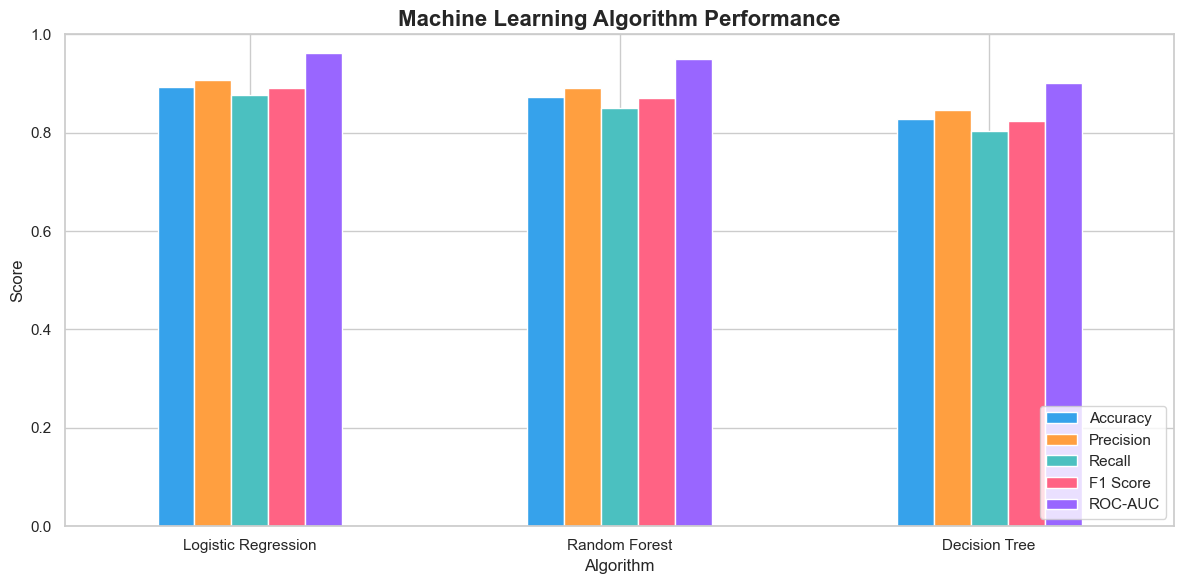

In [5]:
plot_df = results_df.set_index('Algorithm')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, color=['#36a2eb', '#ff9f40', '#4bc0c0', '#ff6384', '#9966ff'])
ax.set_title('Machine Learning Algorithm Performance', fontsize=16, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_xlabel('Algorithm')
plt.xticks(rotation=0)
ax.legend(loc='lower right')
fig.tight_layout()
display(fig)
plt.close(fig)

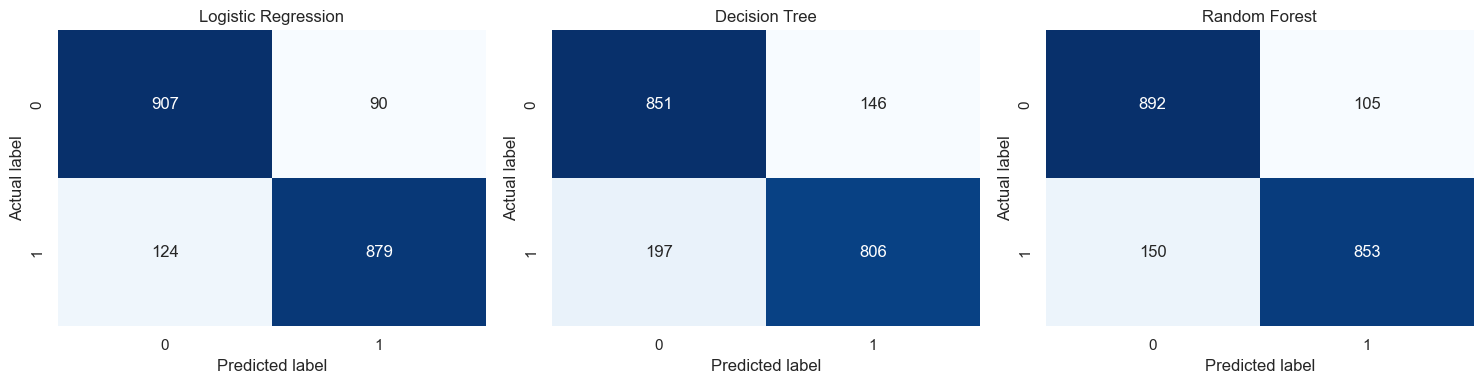

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipeline) in zip(axes, fitted_models.items()):
    predictions = pipeline.predict(X_test)
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Actual label')
fig.tight_layout()
display(fig)
plt.close(fig)

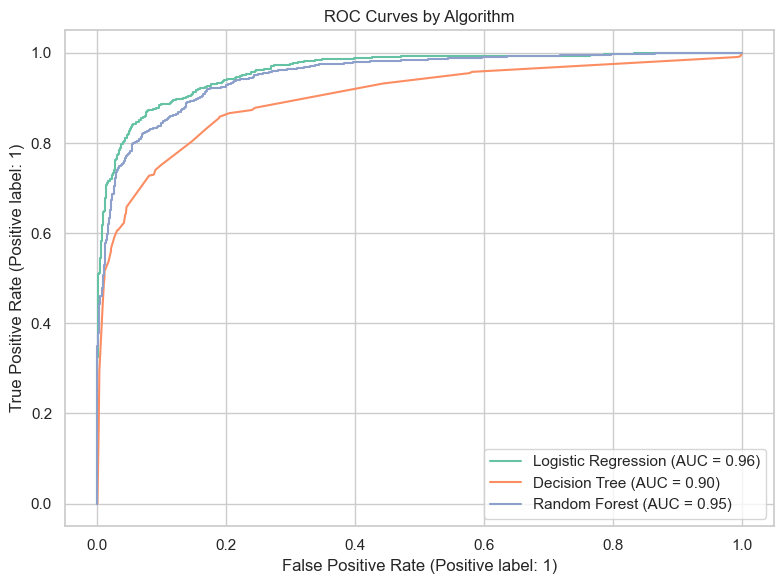

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipeline in fitted_models.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=name, ax=ax)
ax.set_title('ROC Curves by Algorithm')
fig.tight_layout()
display(fig)
plt.close(fig)

## 5. Review the selected algorithm

In [8]:
best_algorithm = results_df.iloc[0]['Algorithm']
print(f'Best exploratory model by F1 Score: {best_algorithm}')
print()
print(classification_report(y_test, fitted_models[best_algorithm].predict(X_test), target_names=['Lower risk', 'Higher risk']))
print('Selection rationale: F1 Score balances precision and recall, which is useful when identifying higher-risk patients without ignoring false negatives.')

Best exploratory model by F1 Score: Logistic Regression

              precision    recall  f1-score   support

  Lower risk       0.88      0.91      0.89       997
 Higher risk       0.91      0.88      0.89      1003

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Selection rationale: F1 Score balances precision and recall, which is useful when identifying higher-risk patients without ignoring false negatives.


## Limitations and relationship to the dashboard

- The high-risk label is created for exploratory comparison and is not a clinically validated outcome.
- The dataset is treated as a single source and results require external validation before operational use.
- Model scores can change with another target threshold, random split, or new data.
- The Streamlit application remains independent: this notebook does not alter `app.py`, dashboard filters, KPI cards, or visualizations.
- No model should be used to diagnose an individual patient or replace qualified clinical judgment.